# Проект:  Приоретизация гипотез и проведение А/В тестирования для интернет-магазина.

**Описание задачи:**

Для крупного интернет-магазина вместе с отделом маркетинга был подготовлен список гипотез для увеличения выручки.

Необходимо приоритизировать гипотезы, запустить A/B-тест, проанализировать результаты.

**Содержание работ:**
    
**1  Чтение данных**

**2  Приоритизация гипотез**

**2.1**  Предобработка данных таблицы с гипотезами

**2.2**  Приоретизация гипотез методами ICE и RICE

**3  Анализ A/B-теста**

**3.1**  Предобрабока данных в таблице с результатами А/В теста по заказам

**3.2**  Предобрабока данных в таблице с результатами А/В теста по визитам

**3.3**  График кумулятивной выручки по группам

**3.4**  График кумулятивного среднего чека по группам

**3.5**  График относительного изменения кумулятивного среднего чека группы B к группе A

**3.6**  График кумулятивного среднего количества заказов на посетителя по группам

**3.7**  График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A

**3.8**  Точечный график количества заказов по пользователям

**3.9**  Расчет 95-й и 99-й перцентили количества заказов на пользователя

**3.10** Точечный график стоимостей заказов

**3.11**  Расчет 95-й и 99-й перцентили стоимости заказов

**3.12**  Расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным

**3.13**  Расчет статистической значимости различий в среднем чеке заказа между группами по «сырым» данным

**3.14**  Расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «очищенным» данным

**3.15**  Расчет статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным

**4  ОБЩИЕ ВЫВОДЫ**

### Чтение данных

In [1]:
# импортируем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
import warnings
# конвертеры, которые позволяют использовать типы pandas в matplotlib  
register_matplotlib_converters()
import scipy.stats as stats
pd.options.display.max_colwidth = 400

In [2]:
# чтение файлов и сохранение в датафреймы
hypothesis, orders, visitors = (
    pd.read_csv('/***'),  # данные с гипотезами
    pd.read_csv('/***'),  # данные с результатами А/В теста по заказам
    pd.read_csv('/***')  # данные с результатами А/В теста по визитам
)

### Приоритизация гипотез.

#### Предобработка данных таблицы с гипотезами.

In [3]:
# Выведем общую информацию о таблице с гипотезами
hypothesis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


In [4]:
print("Таблица с гипотезами и параметрами для приоретизации")
hypothesis

Таблица с гипотезами и параметрами для приоретизации


,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


**Краткое резюме: типы данных верные, пропусков нет, всего 9 записей, рекомендуется привести названия столбцов к нижнему регистру.**

In [5]:
# приведение названия столбцов к нижнему регистру
hypothesis.columns = map(str.lower, hypothesis.columns)
hypothesis

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


#### Приоретизация гипотез методами ICE и RICE

**В таблице hypothesis 9 гипотез по увеличению выручки интернет-магазина. Необходимо выбрать гипотезы, с которых начнется тестирование в первую очередь. Применим фреймворк ICE и RICE для приоритизации гипотез и сравним полученные результаты.**

In [6]:
# приоретизация гипотез методом ICE
hypothesis['ice'] = ((hypothesis['impact']*hypothesis['confidence'])/hypothesis['efforts']).round(3)
hypothesis.sort_values(by='ice',ascending=False)

,hypothesis,reach,impact,confidence,efforts,ice
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.200
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.333
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.200
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.000
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.000
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.000
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.333
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.125
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.000


In [7]:
# приоретизация гипотез методом RICE
hypothesis['rice'] = ((hypothesis['reach']*hypothesis['impact']*hypothesis['confidence'])/hypothesis['efforts']).round(3)
hypothesis.sort_values(by='rice',ascending=False)

,hypothesis,reach,impact,confidence,efforts,ice,rice
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5,11.200,112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3,7.000,56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6,13.333,40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3,8.000,40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5,16.200,16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8,1.125,9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10,2.000,4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3,1.333,4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1,1.000,3.0


**Выводы:**

**Согласно фреймворку ICE в приоритете 3 гипотезы:**

1. Запустить акцию, дающую скидку на товар в день рождения

2. Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей

3. Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок

**Согласно фреймворку RICE в приоритете 3 гипотезы:**

1. Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок

2. Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа

3. Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей

**Разница в приоретизации обуславливается наличием параметра Reach в методе RICE - количество пользователей, которых затронет изменение. В приоритете оказались гипотезы с наибольшим охватом пользователей. Гипотезы по методу RICE в сочетании с охватом пользователей больше коррелируются с задачей увеличить выручку интернет-магазина, поэтому для тестирования выбираем приоретизацию RICE.**


**Краткое заключение по 2 блоку:**

1. Провели предобработку данных в таблице с гипотезами: названия столбцов привели к нижнему регистру.

2. Выбрали метод RICE для приоретизации гипотез. Первыми будут тестироваться гипотезы:

- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок

- Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа

- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей
    
 

### Анализ A/B-теста

#### Предобрабока данных в таблице с результатами А/В теста по заказам

In [8]:
# выведем общую информацию о таблице с результатами А/В теста по заказам
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


In [9]:
print("Таблица с заказами А/В теста")
orders.head()

Таблица с заказами А/В теста


,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


**Краткое резюме: всего 1197 записей, пропусков нет, необходимо привести столбец date к типу date, рекомендуется привести названия столбцов к нижнему регистру.**

In [10]:
# преобразование типа данных столбца date
orders['date'] = pd.to_datetime(orders['date'], format='%Y-%m-%d')
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B


In [11]:
# переименование столбцов, приведение к корректному стилистическому виду
orders = orders.rename(columns={'transactionId': 'transaction_id', 'visitorId': 'visitor_id'})

In [12]:
# контроль обработки данных
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   int64         
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB


In [13]:
# поиск явных дубликатов
orders.duplicated().sum()

0

**Найдем пользователей, которые попали в обе группы, если есть такие.**

In [14]:
# фильтруем пользователей группы А
orders_a = set(orders[orders['group']=='A']['visitor_id'].unique())
# фильтруем пользователей группы В
orders_b = set(orders[orders['group']=='B']['visitor_id'].unique())
# находим список пересечения пользователей 
orders_ab = orders_a & orders_b

print('Количество пользователей, попавших в обе группы:',len(orders_ab))


Количество пользователей, попавших в обе группы: 58


**Для корректного подведения результатов А/В теста, в выборках не должно быть пересечений среди пользователей в группах, удалим из анализа найденных пользователей, попавших в обе группы.** 

In [15]:
# исключаем найденных пользователей 
orders = orders[~orders['visitor_id'].isin(orders_ab)]
# контроль удаления строк
orders.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1016 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1016 non-null   int64         
 1   visitor_id      1016 non-null   int64         
 2   date            1016 non-null   datetime64[ns]
 3   revenue         1016 non-null   int64         
 4   group           1016 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 47.6+ KB


#### Предобрабока данных в таблице с результатами А/В теста по визитам

In [16]:
# выведем общую информацию о таблице с результатами А/В теста по визитам
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [17]:
print("Таблица с посетителями в период проведения А/В теста")
visitors.head()

Таблица с посетителями в период проведения А/В теста


,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


**Краткое резюме: всего 62 записи, пропусков нет, необходимо привести столбец date к типу date.**

In [18]:
# преобразование типа данных столбца date
visitors['date'] = pd.to_datetime(visitors['date'], format='%Y-%m-%d')
visitors.head()

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [19]:
# контроль обработки данных
visitors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


In [20]:
# поиск явных дубликатов
visitors.duplicated().sum()

0

**Краткое заключение по предобработке данных:**

1. Таблица с результатами А/В теста по заказам: найдены и удалены 58 пользователей, попавших в обе группы теста,  пропусков нет, столбец date приведен к типу date

2. Таблица с результатами А/В теста по визитам: дубликатов нет, пропусков нет, столбец date приведен к типу date

#### График кумулятивной выручки по группам. 

**Подготовим данные для построения графика.**

In [21]:
# создаем массив уникальных пар значений дат и групп теста
date_group = orders[['date', 'group']].drop_duplicates()

In [22]:
# формируем агрегированные кумулятивные по дням данные о заказах
orders_aggregated = date_group.apply(
    lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])]
    .agg({  'date': 'max',
            'group': 'max',
            'transaction_id': 'nunique',
            'visitor_id': 'nunique',
            'revenue': 'sum' }),
    axis=1,
).sort_values(by=['date', 'group'])

orders_aggregated.head(10)

,date,group,transaction_id,visitor_id,revenue
55,2019-08-01,A,23,19,142779
66,2019-08-01,B,17,17,59758
175,2019-08-02,A,42,36,234381
173,2019-08-02,B,40,39,221801
291,2019-08-03,A,66,60,346854
383,2019-08-03,B,54,53,288850
499,2019-08-04,A,77,71,388030
498,2019-08-04,B,68,66,385740
719,2019-08-05,A,99,92,474413
699,2019-08-05,B,89,87,475648


In [23]:
# сформируем агрегированные кумулятивные по дням данные о посетителях

visitors_aggregated = date_group.apply(
    lambda x: visitors[
        np.logical_and(
            visitors['date'] <= x['date'], visitors['group'] == x['group']
        )
    ].agg({'date': 'max',
           'group': 'max',
           'visitors': 'sum'}),
    axis=1,
).sort_values(by=['date', 'group'])

visitors_aggregated.head()

,date,group,visitors
55,2019-08-01,A,719
66,2019-08-01,B,713
175,2019-08-02,A,1338
173,2019-08-02,B,1294
291,2019-08-03,A,1845


In [24]:
# объединим таблицы в одну

cumulative_data = orders_aggregated.merge(
    visitors_aggregated, left_on=['date', 'group'], right_on=['date', 'group']
)
cumulative_data.columns = [
    'date',
    'group',
    'transactions',
    'buyers',
    'revenue',
    'visitors',
]
cumulative_data.head()

,date,group,transactions,buyers,revenue,visitors
0,2019-08-01,A,23,19,142779,719
1,2019-08-01,B,17,17,59758,713
2,2019-08-02,A,42,36,234381,1338
3,2019-08-02,B,40,39,221801,1294
4,2019-08-03,A,66,60,346854,1845


In [25]:
# контроль пропусков после объединения
cumulative_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 62 entries, 0 to 61
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          62 non-null     datetime64[ns]
 1   group         62 non-null     object        
 2   transactions  62 non-null     int64         
 3   buyers        62 non-null     int64         
 4   revenue       62 non-null     int64         
 5   visitors      62 non-null     int64         
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 3.4+ KB


In [26]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_A = cumulative_data[cumulative_data['group']=='A'][['date','revenue', 'transactions']]

# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_B = cumulative_data[cumulative_data['group']=='B'][['date','revenue', 'transactions']]

In [27]:
# вывод датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_A

,date,revenue,transactions
0,2019-08-01,142779,23
2,2019-08-02,234381,42
4,2019-08-03,346854,66
6,2019-08-04,388030,77
8,2019-08-05,474413,99
10,2019-08-06,515332,114
12,2019-08-07,638580,130
14,2019-08-08,727219,144
16,2019-08-09,861456,155
18,2019-08-10,1013731,170


In [28]:
# вывод датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_B

,date,revenue,transactions
1,2019-08-01,59758,17
3,2019-08-02,221801,40
5,2019-08-03,288850,54
7,2019-08-04,385740,68
9,2019-08-05,475648,89
11,2019-08-06,690490,112
13,2019-08-07,909654,135
15,2019-08-08,1059795,157
17,2019-08-09,1162961,176
19,2019-08-10,1268123,198


**Строим графики кумулятивной выручки по дням и группам A/B-тестирования**

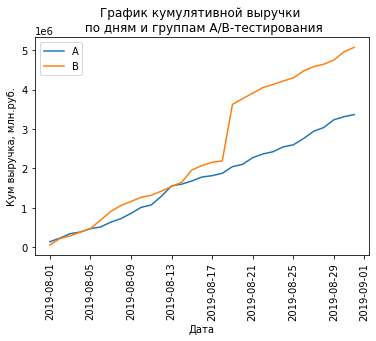

In [29]:
# Строим график выручки группы А
plt.plot(cumulative_revenue_A['date'], cumulative_revenue_A['revenue'], label='A')

# Строим график выручки группы B
plt.plot(cumulative_revenue_B['date'], cumulative_revenue_B['revenue'], label='B')

# подписи графика
plt.title('График кумулятивной выручки \n по дням и группам A/B-тестирования')
plt.xlabel('Дата')
plt.ylabel('Кум выручка, млн.руб.')
plt.legend()
plt.xticks(rotation=90)
plt.show()

**Выручка растет в обеих группах в течение всего теста. В группе А рост выручки равномерный, с незначительным всплеском 13.08.2019. В группе В выручка имеет резкий значительный скачок между 17.08 и 21.08 . 
Скачки могут сигнализировать о всплесках числа заказов, либо о появлении очень дорогих заказов в выборке. Будем иметь ввиду выбросы в дальнейшем анализе.**

#### График кумулятивного среднего чека по группам. 

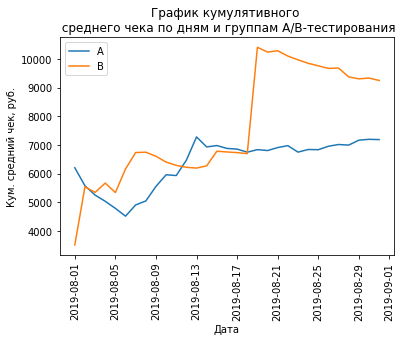

In [30]:
# Строим график среднего чека группы А
plt.plot(cumulative_revenue_A ['date'],
         cumulative_revenue_A ['revenue']/cumulative_revenue_A ['transactions'], label='A')
# Строим график среднего чека группы В
plt.plot(cumulative_revenue_B ['date'],
         cumulative_revenue_B ['revenue']/cumulative_revenue_B ['transactions'], label='B')

# подписи графика
plt.title('График кумулятивного \n среднего чека по дням и группам A/B-тестирования')
plt.xlabel('Дата')
plt.ylabel('Кум. средний чек, руб.')
plt.legend()
plt.xticks(rotation=90)
plt.show()


**Динамика куммулятивного среднего чека в обеих группах нестабильна с явными скачками и падениями.**

**В группе А наблюдается значительное падение вначале теста, похоже, что было много заказов с маленькими суммами, либо какой-то технический сбой в интернет-магазине в период со 02.08 по 10.08, так как 10.08 средний чек становится таким же как на старте теста. Есть небольшой скачок 13.08, скорее всего , в группу попали  крупные суммы заказов. С середины теста происходит выравнивание среднего чека с плавным ростом. Динамика среДнего чека группы А выглядит более стабильно по сравнению с динамикой среднего чека группы В.**

**Кумулятивный средний чек группы В развивается скачкообразно с резкими перепадами. Средний чек вырос за период теста в 2 раза. Резкий рост наблюдается с 17.08 по 21.08, из графика коммулятивной выручки в этот же период происходит резкий скачок, что свидетельствует о значительном увеличении сумм заказов. Стабилизация среднего чека происходит в последней трети периода, но с плавным падением. Средний чек группы В практически весь период выше среднего чека группы А, но стоит обратить внимание на 13.08, где средний чек группы В падает, а группа  А, наоборот, растет и становится выше группы В.** 



#### График относительного изменения кумулятивного среднего чека группы B к группе A. 

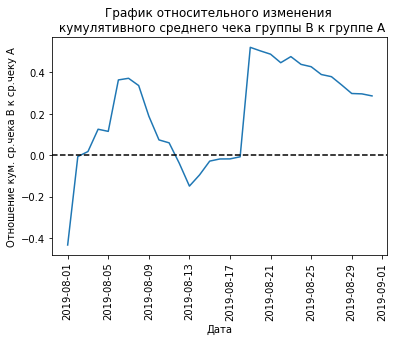

In [31]:
# собираем данные в одном датафрейме
cumulative_revenue_AB = cumulative_revenue_A.merge(cumulative_revenue_B, left_on='date',
                                                   right_on='date', how='left', suffixes=['A', 'B'])

# cтроим отношение средних чеков
plt.plot(cumulative_revenue_AB['date'],
         (cumulative_revenue_AB['revenueB']/cumulative_revenue_AB['transactionsB'])/
         (cumulative_revenue_AB['revenueA']/cumulative_revenue_AB['transactionsA'])-1)

# добавляем ось X
plt.axhline(y=0, color='black', linestyle='--') 

# подписи графика
plt.title('График относительного изменения \n кумулятивного среднего чека группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Отношение кум. ср.чека В к ср.чеку А')
plt.xticks(rotation=90)
plt.show()

**Общая динамика показывает, что средний чек группы В выше, до 50%. Но в середине теста наблюдается резкое падение . Ещё одно подтверждение, что в группах есть крупные заказы и выбросы.**

#### График кумулятивного среднего количества заказов на посетителя по группам.

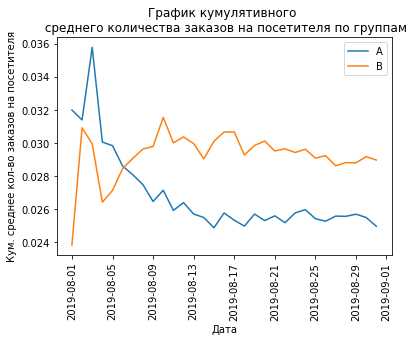

In [32]:
# считаем среднее количество заказов на посетителя
cumulative_data['conversion'] = cumulative_data['transactions']/cumulative_data['visitors']

# отделяем данные по группе A
cumulative_data_A = cumulative_data[cumulative_data['group']=='A']

# отделяем данные по группе B
cumulative_data_B = cumulative_data[cumulative_data['group']=='B']

# строим графики
plt.plot(cumulative_data_A['date'], cumulative_data_A['conversion'], label='A')
plt.plot(cumulative_data_B['date'], cumulative_data_B['conversion'], label='B')

# подписи графика
plt.title('График кумулятивного \n среднего количества заказов на посетителя по группам')
plt.xlabel('Дата')
plt.ylabel('Кум. среднее кол-во заказов на посетителя')
plt.xticks(rotation=90)
plt.legend()
plt.show()


**Первые 5 дней теста наблюдается большая амплитуда колебаний в каждой группе, где в лидерах группа А по среднему кол-ву заказов на посетителя. После первых 5-ти дней группа В становится стабильно выше.** 

**Обе группы зафиксировалось в середине теста, каждая с небольшими колебаниями на своем уровне. Группа В к концу теста незначительно падает, а группа А держится на одном уровне.** 

#### График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A. 

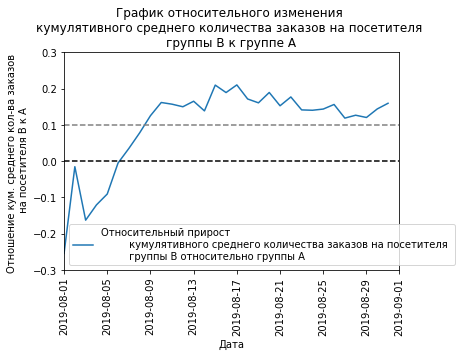

In [33]:
# собираем данные в одном датафрейме
cumulative_conversions = (
    cumulative_data_A[['date','conversion']]
    .merge(cumulative_data_B[['date','conversion']],
           left_on='date', right_on='date', how='left', suffixes=['A', 'B']))
# cтроим отношение среднего количества заказов на посетителя
plt.plot(cumulative_conversions['date'],
         cumulative_conversions['conversionB']/cumulative_conversions['conversionA']-1,
         label="Относительный прирост \n\
         кумулятивного среднего количества заказов на посетителя \n\
         группы B относительно группы A")

# подписи графика
plt.title('График относительного изменения \n\
кумулятивного среднего количества заказов на посетителя \n\
группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Отношение кум. среднего кол-ва заказов \n на посетителя В к А')
plt.xticks(rotation=90)
plt.legend()
plt.axhline(y=0, color='black', linestyle='--')
plt.axhline(y=0.1, color='grey', linestyle='--')
plt.axis(["2019-08-01", '2019-09-01', -0.3, 0.3]) 
plt.show()


**На данной графике видно, как группа В начинает лидировать после 5-ти дней теста по среднему кол-ву заказов на посетителя. В середине теста Группа В выше на 10-20%, к последней трети теста наблюдается стабилизация и разница снижается до 10-15%.**

**Подсчитаем количество заказов по каждому пользователю и построим точечную диаграмму числа заказов на одного пользователя.**

#### Точечный график количества заказов по пользователям.

In [34]:
orders.head()

,transaction_id,visitor_id,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B
5,182168103,935554773,2019-08-15,2210,B


In [35]:
# формируем датафрейм с кол-вом заказов по каждому пользователю
orders_users = (
    orders.groupby('visitor_id', as_index=False)
    .agg({'transaction_id': 'nunique'})
)

orders_users.columns = ['visitor_id', 'transactions']

orders_users.sort_values(by='transactions', ascending=False).head(10)

,visitor_id,transactions
908,3967698036,3
55,249864742,3
478,2108163459,3
687,2988190573,3
890,3908431265,3
138,611059232,3
632,2742574263,3
157,678354126,2
323,1404560065,2
452,1985475298,2


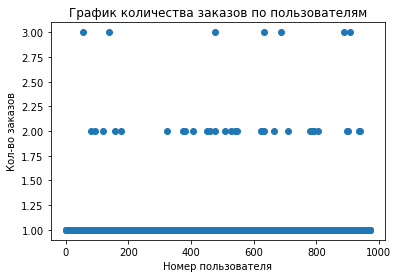

In [36]:
# создаем Series с номером пользователя
x_values = pd.Series(range(0,len(orders_users)))
# строим график
plt.scatter(x_values, orders_users['transactions'])
plt.title('График количества заказов по пользователям')
plt.xlabel('Номер пользователя')
plt.ylabel('Кол-во заказов')
plt.show()

**На графике видно, что пользователи чаще всего совершают 1 покупку. Также есть пользователи, совершивших 2 и 3 покупки.**

**Чтобы понять, какое кол-во заказов можно считать аномальными, рассчитаем перцентили заказов на пользователя.**

#### Расчет 95-й и 99-й перцентили количества заказов на пользователя. 

In [37]:
print(np.percentile(orders_users['transactions'], [90, 95, 99]))

[1. 1. 2.]


**Не более 5% пользователей совершили больше одной покупки и не более 1% больше 2-ух заказов. Чтобы не потерять качество данных, мы можем отсеять до 5% данных, примем 2 заказа на одного пользователя за верхнюю границу числа заказов, а заказы свыше считаем аномальными.**

**Сделаем тоже самое с суммами заказов, чтобы определить аномалии.**

#### Точечный график стоимостей заказов. 

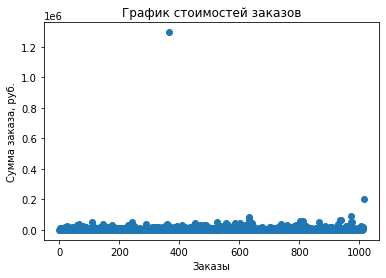

In [38]:
# создаем Series с порядковым номером заказа
x_values = pd.Series(range(0,len(orders['revenue'])))
# строим график
plt.scatter(x_values, orders['revenue']) 
plt.title('График стоимостей заказов')
plt.xlabel('Заказы')
plt.ylabel('Сумма заказа, руб.')
plt.show()

**На графике видно 2 очень крупных заказа, из-за которых остальные заказы сливаются в одну линию. Построим новый тотечный график, исключив данные заказы, диапазон с суммами заказов до 100 000 руб.**

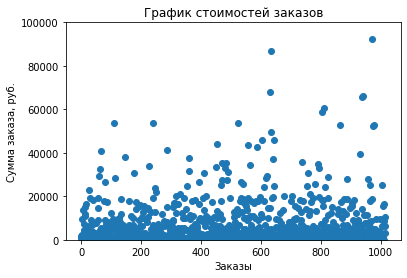

In [39]:
# строим график с заданным диапазоном
plt.scatter(x_values, orders['revenue']) 
plt.title('График стоимостей заказов')
plt.xlabel('Заказы')
plt.ylabel('Сумма заказа, руб.')
plt.ylim(0, 100000)
plt.show()

**На данном графике визуально можно выделить самыми частыми заказами на сумму до 20 000 руб. Чтобы опредлить точно аномалии посчитаем 95-й и 99-й перцентили.**

#### Расчет  95-й и 99-й перцентили стоимости заказов. 

In [40]:
print(np.percentile(orders['revenue'], [90, 95, 99]))

[17990. 26785. 53904.]


**Не более 5% заказов на сумму свыше 26785 руб. и не более 1% заказов на сумму от 53904 руб. За верхнюю границу суммы заказа принимем также 99 перцентиль , с суммой 53904 руб. Все заказы свыше считаем аномальными.**

#### Расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «сырым» данным.

**По визуальной оценке результатов A/B-теста выяснили, что в данных, скорее всего, есть выбросы;
Их границу определили по 95-му перцентилю.**

**Теперь посчитаем сначала статистическую значимость различий в среднем числе заказов на пользователя и среднем чеке между группами по «сырым» данным — без удаления аномальных пользователей.**

**Сформулируем гипотезы.**

- Нулевая: различий в среднем количестве заказов между группами нет.

- Альтернативная: различия в среднем количестве заказов между группами есть.

In [41]:
# создаем таблицу с количеством пользователей по датам в группе A
visitors_daily_A = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitors_daily_A.columns = ['date', 'visitors_daily_A']
visitors_daily_A.head(3)


,date,visitors_daily_A
0,2019-08-01,719
1,2019-08-02,619
2,2019-08-03,507


In [42]:
# создаем таблицу с количеством пользователей по датам в группе В
visitors_daily_B = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitors_daily_B.columns = ['date', 'visitors_daily_B']
visitors_daily_B.head(3)

,date,visitors_daily_B
31,2019-08-01,713
32,2019-08-02,581
33,2019-08-03,509


In [43]:
# создаем таблицу с куммулятивным количеством пользователей по датам в группе A
visitors_cummulative_A = visitors_aggregated[visitors_aggregated['group'] == 'A'][['date', 'visitors']]
visitors_cummulative_A.columns = ['date', 'visitors_cummulative_A']
visitors_cummulative_A.head(3)

,date,visitors_cummulative_A
55,2019-08-01,719
175,2019-08-02,1338
291,2019-08-03,1845


In [44]:
# создаем таблицу с куммулятивным количеством пользователей по датам в группе B
visitors_cummulative_B = visitors_aggregated[visitors_aggregated['group'] == 'B'][['date', 'visitors']]
visitors_cummulative_B.columns = ['date', 'visitors_cummulative_B']
visitors_cummulative_B.head(3)

,date,visitors_cummulative_B
66,2019-08-01,713
173,2019-08-02,1294
383,2019-08-03,1803


In [45]:
# создаем таблицу с количеством заказов и выручкой по датам в группе A
orders_daily_A = (
    orders[orders['group'] == 'A'][['date', 'transaction_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
orders_daily_A.columns = ['date', 'transaction_daily_A', 'revenue_daily_A']
orders_daily_A.head(3)

,date,transaction_daily_A,revenue_daily_A
0,2019-08-01,23,142779
1,2019-08-02,19,91602
2,2019-08-03,24,112473


In [46]:
# создаем таблицу с количеством заказов и выручкой по датам в группе B
orders_daily_B = (
    orders[orders['group'] == 'B'][['date', 'transaction_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
orders_daily_B.columns = ['date', 'transaction_daily_B', 'revenue_daily_B']
orders_daily_B.head(3)

,date,transaction_daily_B,revenue_daily_B
0,2019-08-01,17,59758
1,2019-08-02,23,162043
2,2019-08-03,14,67049


In [47]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе А
cumulative_revenue_A.columns = ['date','revenue_cumulative_A', 'transactions_cumulative_A']
cumulative_revenue_A.head(3)

,date,revenue_cumulative_A,transactions_cumulative_A
0,2019-08-01,142779,23
2,2019-08-02,234381,42
4,2019-08-03,346854,66


In [48]:
# датафрейм с кумулятивным количеством заказов и кумулятивной выручкой по дням в группе B
cumulative_revenue_B.columns = ['date','revenue_cumulative_B', 'transactions_cumulative_B']
cumulative_revenue_B.head(3)

,date,revenue_cumulative_B,transactions_cumulative_B
1,2019-08-01,59758,17
3,2019-08-02,221801,40
5,2019-08-03,288850,54


In [49]:
# объединим данные
data = (
    orders_daily_A.merge(
        orders_daily_B, left_on='date', right_on='date', how='left'
    )
    .merge(cumulative_revenue_A, left_on='date', right_on='date', how='left')
    .merge(cumulative_revenue_B, left_on='date', right_on='date', how='left')
    .merge(visitors_daily_A, left_on='date', right_on='date', how='left')
    .merge(visitors_daily_B, left_on='date', right_on='date', how='left')
    .merge(visitors_cummulative_A, left_on='date', right_on='date', how='left')
    .merge(visitors_cummulative_B, left_on='date', right_on='date', how='left')
)

data.head(5)

,date,transaction_daily_A,revenue_daily_A,transaction_daily_B,revenue_daily_B,revenue_cumulative_A,transactions_cumulative_A,revenue_cumulative_B,transactions_cumulative_B,visitors_daily_A,visitors_daily_B,visitors_cummulative_A,visitors_cummulative_B
0,2019-08-01,23,142779,17,59758,142779,23,59758,17,719,713,719,713
1,2019-08-02,19,91602,23,162043,234381,42,221801,40,619,581,1338,1294
2,2019-08-03,24,112473,14,67049,346854,66,288850,54,507,509,1845,1803
3,2019-08-04,11,41176,14,96890,388030,77,385740,68,717,770,2562,2573
4,2019-08-05,22,86383,21,89908,474413,99,475648,89,756,707,3318,3280


In [50]:
# создаем датафрейм со списком покупателей и их кол-вом заказов для группы А, которые заказывали хотя бы 1 раз
orders_users_A = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
orders_users_A.columns = ['visitor_id', 'transactions_count']
# создаем датафрейм со списком покупателей и их кол-вом заказов для группы B, которые заказывали хотя бы 1 раз
orders_users_B = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
orders_users_B.columns = ['visitor_id', 'transactions_count']

**Создадим выборки, в которых пользователям из разных групп будет соответствовать количество заказов. Тем, кто ничего не заказал, будут соответствовать нули. Это нужно, чтобы подготовить выборки к проверке критерием Манна-Уитни.**

In [51]:
# создадим выборку, где каждый элемент — число заказов определённого пользователя в гуппе А
sample_A = (
    pd.concat([orders_users_A['transactions_count'],
               pd.Series(0, index=np.arange(data['visitors_daily_A']
                                            .sum()- len(orders_users_A['transactions_count'])),
                         name='transactions_count')],axis=0))
# создадим выборку, где каждый элемент — число заказов определённого пользователя в гуппе B
sample_B = (
    pd.concat([orders_users_B['transactions_count'],
               pd.Series(0, index=np.arange(data['visitors_daily_B']
                                            .sum()- len(orders_users_B['transactions_count'])),
                         name='transactions_count')],axis=0))
sample_B.head()

0    1
1    1
2    1
3    1
4    1
Name: transactions_count, dtype: int64

**Посчитаем статистическую значимость различий в среднем количестве заказов на посетителя между группами по «сырым» данным.**

In [52]:
print('Критерий p-value равен:'"{0:.3f}".format(stats.mannwhitneyu(sample_A, sample_B)[1]))

print('Относительный прирост среднего числа заказов группы B к группе А :',
      "{0:.3f}".format(sample_B.mean() / sample_A.mean() - 1))

Критерий p-value равен:0.011
Относительный прирост среднего числа заказов группы B к группе А : 0.160


**Если сравнивать "сырые" данные обеих групп, с аномалиями: Критерий p-value меньше 0.05. Значит, нулевую гипотезу о том, что статистически значимых различий в среднем числе заказов между группами нет,  отвергаем. Группа В статистически превышает группу А на 16%.**

#### Расчет статистической значимости различий в среднем чеке заказа между группами по «сырым» данным.

**Сформулируем гипотезы.**

- Нулевая: различий в среднем чеке заказов между группами нет.

- Альтернативная: различия в среднем чеке между группами есть.

In [53]:
print('Критерий p-value равен:''{0:.3f}'
      .format(stats.
              mannwhitneyu(orders[orders['group']=='A']['revenue'],
                           orders[orders['group']=='B']['revenue'])[1]))
print('Относительный прирост среднего чека группы B к группе А: ''{0:.3f}'
      .format(orders[orders['group']=='B']['revenue'].mean()/
              orders[orders['group']=='A']['revenue'].mean()-1)) 

Критерий p-value равен:0.829
Относительный прирост среднего чека группы B к группе А: 0.287


**Если сравнивать "сырые" данные обеих групп, с аномалиями: Критерий p-value больше 0.05. Значит, нулевую гипотезу не отвергаем , статистически значимых различий в среднем чеке между группами нет. Однако, относительное различие среднего чека между группами 28,7%, наблюдаемое различие не является статистически значимым, скорее всего повлияли ранее отмеченные аномалии.**

**Рассчитаем статистическую значимость по заказам и среднему чеку с очищенными данными.**

#### Расчет статистической значимости различий в среднем количестве заказов на посетителя между группами по «очищенным» данным.

**Сформулируем гипотезы.**

- Нулевая: различий в среднем количестве заказов между группами нет.

- Альтернативная: различия в среднем количестве заказов между группами есть.

In [54]:
# определим пользователей с аномальным кол-вом заказов или суммой заказа
users_many_orders = pd.concat(
    [orders_users_A[orders_users_A['transactions_count'] > 2]['visitor_id'],
     orders_users_B[orders_users_B['transactions_count'] > 1]['visitor_id']], axis=0)

users_expensive_orders = orders[orders['revenue'] > 53904]['visitor_id']
abnormal_users = (
    pd.concat([users_many_orders, users_expensive_orders], axis=0)
    .drop_duplicates()
    .sort_values()
)
print(abnormal_users.head(5))

print('Всего аномальных пользователей:',abnormal_users.shape[0]) 

1099    148427295
33      249864742
51      406208401
67      522292794
58      611059232
Name: visitor_id, dtype: int64
Всего аномальных пользователей: 32


In [55]:
# исключим из данных аномальных пользователей
filtered_A = pd.concat(
    [orders_users_A[
        np.logical_not(orders_users_A['visitor_id'].isin(abnormal_users))]['transactions_count'],
        pd.Series(0,index=np.arange(data['visitors_daily_A'].sum() -\
                                    len(orders_users_A['transactions_count'])),name='orders')], axis=0)

filtered_B = pd.concat(
    [orders_users_B[np.logical_not(orders_users_B['visitor_id'].isin(abnormal_users))]['transactions_count'],
        pd.Series(0,index=np.arange(data['visitors_daily_B'].sum() -\
                                    len(orders_users_B['transactions_count'])),name='orders')],axis=0)

In [56]:
print('Критерий p-value равен: ''{0:.3f}'.format(stats.mannwhitneyu(filtered_A, filtered_B)[1]))
print('Относительный прирост среднего числа заказов группы B к группе А: '
      '{0:.3f}'.format(filtered_B.mean()/filtered_A.mean()-1)) 

Критерий p-value равен: 0.028
Относительный прирост среднего числа заказов группы B к группе А: 0.119


**По очищенным данным статистически значимые различия тажке не обнаружены: критерий p-value меньше 0,05. Относительный прирост среднего числа заказов группы B к группе А изменился с 16% до 11,9%. Итого нулевую гипотезу отвергаем: в среднем кол-ве заказов на пользователя есть статистически значимые различия.**

#### Расчет статистической значимости различий в среднем чеке заказа между группами по «очищенным» данным.

In [57]:
print('Критерий p-value равен:'
    '{0:.3f}'.format(stats.mannwhitneyu(
            orders[np.logical_and(orders['group'] == 'A',
                    np.logical_not(orders['visitor_id'].isin(abnormal_users)))]['revenue'],
            orders[np.logical_and(orders['group'] == 'B',
                    np.logical_not(orders['visitor_id'].isin(abnormal_users)))]['revenue'])[1])
)

print('Относительный прирост среднего чека группы B к группе А: '
    "{0:.3f}".format(
        orders[np.logical_and(orders['group'] == 'B',
                np.logical_not(orders['visitor_id'].isin(abnormal_users)))]['revenue'].mean()/
        orders[ np.logical_and(orders['group'] == 'A',
                np.logical_not(orders['visitor_id'].isin(abnormal_users)))]['revenue'].mean()- 1)
) 

Критерий p-value равен:0.777
Относительный прирост среднего чека группы B к группе А: -0.015


**После очистки данных: критерий p-value выше 0,05. В сырых данных группа В превышала на 25,9% группу А, поле очистки разница стремится к 0, всего лишь 1,5%, при этом в пользу не группы В, а группы А. Нулевую гипотезу не удалось отвергнуть, статистически значимых различий в среднем чеке между группами не выявлено.**

### ОБЩИЕ ВЫВОДЫ

В процессе анализа были выполнены следующие шаги:
    
1. Провели приоретизацию 9 гипотез фреймворками  ICE и RICE. Были выбраны для тестирования гипотезы по методу RICE, так как данный метод учитывает охват пользователей, что позволит более вероятно увеличить выручку интернет-магазина. Первые 3 гипотезы , выбранные для тестирования:

- Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок

- Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа

- Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей

2. Провели предобработку данных с результатами А/В тестирования:

- В данных с заказами  удалили 58 пользователей, которые попали в обе группы теста, столбец date преобразовали к типу date, названия столбцов привели к нижнему регистру.

- В данных с визитами столбец date преобразовали к типу date.

3. Проанализировали результаты А/В тестирования и пришли к следующим выводам:

3.1 Выручка растет в обеих группах в течение всего теста. Группа В доминирует по выручке. В группе А рост выручки достаточно равномерный, у группы В есть значительный скачок, который обуславливается выбросами. 

3.2. Провели статистический анализ данных и выявили, что выручка в группе В выше за счёт бОльшего числа заказов:

- Расчет выявил статистически значимые различия по среднему кол-ву заказов на одного пользователя между группами как по сырым данным, так и после фильтрации аномалий. По сырым данным группа В статистически превышает группу А на 13,8%, после очистки относительный прирост увеличился до 17,3%.


- По сырым данным и по очищенным  статистически значимого различия по среднему чеку между группами не обнаружено. По сырым данным средний чек группы В превышал на 25,9%, однако показатель p-value больше 0,05. После очистки аномально крупных заказов, разница устремилась к 0, всего лишь 2%, при этом в пользу не группы В, а группы А.

3.3. График различия среднего кол-ва заказов на пользователя между группами сообщает, что 
после первых 5-ти дней группа В становится стабильно выше. Обе группы зафиксировались в середине теста, каждая с небольшими колебаниями на своем уровне. Группа В к концу теста незначительно падает, а группа А незначительно растет.

3.4. График различия среднего чека колеблется, обе группы растут, но в середне периода наблюдается резкий скачок в группе В и куммулятивный средний чек вырастает в 2 раза. Но после очистки данных мы выявили, что разницы в среднем чеке нет в обеих группах.

**Исходя из обнаруженных фактов, и учитывая длительность тестирования, тест следует остановить, признать его успешным и перейти к проверке следующей гипотезы.**